In [10]:
import os
import pandas as pd
import ROOT
import pickle
import csv
import uproot
import numpy as np
import mplhep as hep
import awkward as ak
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.optimize import curve_fit
from array import array
from tqdm import trange, tqdm
import random
import time 
import hist
from uncertainties import unumpy as unp
from IPython.display import display, Image

In [2]:
def normalize_histogram_with_uncertainty(histogram, input_format=None, output_format=None, flow=False):
    """
    Normalize a histogram with uncertainty propagation and support for uproot, ROOT, and hist.Hist formats.

    Args:
        histogram: Input histogram (uproot, ROOT, or hist.Hist).
        input_format (str): Format of the input histogram ("uproot", "ROOT", or "hist.Hist").
        output_format (str): Desired format of the output histogram ("uproot", "ROOT", or "hist.Hist").
        flow (bool): Whether to include underflow and overflow bins in normalization.

    Returns:
        Normalized histogram in the specified output format.
    """
    # Detect input format if not specified
    if input_format is None:
        if isinstance(histogram, hist.Hist):
            input_format = "hist"
        elif isinstance(histogram, ROOT.TH1):
            input_format = "ROOT"
        elif hasattr(histogram, "values") and hasattr(histogram, "axes"):
            input_format = "uproot"
        else:
            raise ValueError("Unable to detect input histogram format. Specify input_format.")

    # Extract values, variances, and edges based on input format
    if input_format == "hist":
        values = histogram.values(flow=flow)
        variances = histogram.variances(flow=flow)
        edges = histogram.axes[0].edges
        hist_name = "normalized by bin width"
    elif input_format == "ROOT":
        nbins = histogram.GetNbinsX()
        values = np.array([histogram.GetBinContent(i + 1) for i in range(nbins)])
        variances = np.array([histogram.GetBinError(i + 1)**2 for i in range(nbins)])
        edges = np.array([histogram.GetBinLowEdge(i + 1) for i in range(nbins + 1)])
        hist_name = histogram.GetName()
    elif input_format == "uproot":
        values = histogram.values()
        variances = histogram.variances()
        edges = histogram.axes[0].edges()
        hist_name = histogram.to_hist().name
    else:
        raise ValueError("Unsupported input_format. Use 'uproot', 'ROOT', or 'hist.Hist'.")

    #print(edges)

    # Handle cases with no entries
    total_value = np.sum(values)
    if total_value == 0:
        return histogram  # Return as-is if total is zero

    # Create array with uncertainties using unumpy
    values_with_uncert = unp.uarray(values, np.sqrt(variances))

    # Normalize the values with uncertainty propagation
    normalized_values = values_with_uncert / total_value

    # Determine output format if not provided
    if output_format is None:
        output_format = input_format

    # Generate the normalized histogram based on requested output format
    if output_format == "hist":
        normalized_hist = hist.Hist(
            histogram.axes[0],
            name=hist_name, 
            storage=hist.storage.Weight()
        )
        normalized_hist[...] = (unp.nominal_values(normalized_values),
                                unp.std_devs(normalized_values)**2)
        return normalized_hist

    elif output_format == "ROOT":
        h_density = ROOT.TH1D(hist_name, hist_name, len(values), edges[0], edges[-1])
        for i in range(len(values)):
            h_density.SetBinContent(i + 1, unp.nominal_values(normalized_values)[i])
            h_density.SetBinError(i + 1, unp.std_devs(normalized_values)[i])
        return h_density

    elif output_format == "uproot":
        h_density = hist.Hist.new.Reg(len(values), edges[0], edges[-1], name=hist_name).Double()
        h_density.view(flow=False)[...] = unp.nominal_values(normalized_values)
        h_density.variances(flow=False)[...] = unp.std_devs(normalized_values)**2
        return h_density

    else:
        raise ValueError("Unsupported output_format. Use 'uproot', 'ROOT', or 'hist.Hist'.")

# Example usage
# Assuming `h` is a histogram in one of the supported formats
# normalized_h = normalize_histogram_with_uncertainty(h, input_format="ROOT", output_format="hist.Hist")


In [69]:
merged_hists['gen_b1j'].label

'gen_b1j'

In [12]:
op_values = ['-8', '-4', '-2', '0', '2', '4', '8']

for value in op_values:
    
    path = f"/depot/cms/top/he614/notebooks/EFT_FullRun2/histogram_output_2016*VFP_partonEFT*{value}*/Nominal/*plustau*"
    plustau_paths = !realpath {path}
    from collections import defaultdict
    # Dictionary to hold merged histograms per variable
    merged_hists = defaultdict(lambda: None)
    
    for path in plustau_paths:
        with open(path, "rb") as f:
            hist_dict = pickle.load(f)  # a dict of {var_name: hist.Hist}
    
            for var, h in hist_dict.items():
                if merged_hists[var] is None:
                    merged_hists[var] = h.copy()
                else:
                    merged_hists[var] += h
    
    xy_labels = []
    
    # Ensure consistent order of keys (e.g., sort alphabetically or by a defined order)
    var_names = sorted(merged_hists.keys())
    
    # Assuming 6 bins per variable
    for var in var_names:
        for i in range(6):
            label = f"{var}, bin {i}"
            xy_labels.append(label)

    # Extract values and variances from all histograms
    flattened = []
    
    for var_name, h in merged_hists.items():
        values = h.values()
        variances = h.variances()
        assert values.shape == variances.shape, f"Shape mismatch in {var_name}"
        flattened.append((values.flatten(), variances.flatten()))
    
    # Concatenate into a single array
    all_values = np.concatenate([vals for vals, _ in flattened])
    all_variances = np.concatenate([vars for _, vars in flattened])
    
    # Create a 1D histogram with unit-width bins
    n_bins = len(all_values)
    bin_edges = np.arange(n_bins + 1)
    
    big_hist = hist.Hist(
        hist.axis.Variable(bin_edges, name="observable"),
        storage=hist.storage.Weight()
    )
    
    norm_values_all = []
    norm_variances_all = []
    
    # Normalize each 6-bin observable block
    for i in range(0, len(all_values), 6):
        vals = all_values[i:i+6]
        vars_ = all_variances[i:i+6]
    
        # Get bin edges and widths for this observable
        sub_edges = bin_edges[i:i+7]  # 6 bins → 7 edges
        bin_widths = np.diff(sub_edges)
    
        # Use unumpy for proper error propagation
        uvals = unp.uarray(vals, np.sqrt(vars_))
        uvals_density = uvals / sum(uvals) / bin_widths
    
        # Save normalized values and variances
        norm_values_all.append(unp.nominal_values(uvals_density))
        norm_variances_all.append(unp.std_devs(uvals_density)**2)
    
    # Flatten the results
    norm_values_flat = np.concatenate(norm_values_all)
    norm_variances_flat = np.concatenate(norm_variances_all)
    
    # Fill histogram with normalized bin content and uncertainties
    values_with_variances = np.array(
        [(val, var) for val, var in zip(norm_values_flat, norm_variances_flat)],
        dtype=[("value", "f8"), ("variance", "f8")]
    )
    big_hist[...] = values_with_variances
    
    # Save to ROOT
    with uproot.recreate(f"concatenated_histograms_ctg{value}.root") as fout:
        fout["diff_cross_section"] = big_hist
    
    print(f"Saved concatenated histogram to: concatenated_histograms_ctg{value}.root")

xy_labels = []

# Ensure consistent order of keys (e.g., sort alphabetically or by a defined order)
var_names = merged_hists.keys()

# Assuming 6 bins per variable
for var in var_names:
    for i in range(6):
        label = f"{var}, bin {i}"
        xy_labels.append(label.replace('gen_','').replace(', bin',''))

xy_labels_reduced = [
    label for i, label in enumerate(xy_labels)
    if i % 6 != 1
]

print(len(xy_labels))
print(len(xy_labels_reduced))

Saved concatenated histogram to: concatenated_histograms_ctg-8.root
Saved concatenated histogram to: concatenated_histograms_ctg-4.root
Saved concatenated histogram to: concatenated_histograms_ctg-2.root
Saved concatenated histogram to: concatenated_histograms_ctg0.root
Saved concatenated histogram to: concatenated_histograms_ctg2.root
Saved concatenated histogram to: concatenated_histograms_ctg4.root
Saved concatenated histogram to: concatenated_histograms_ctg8.root
228
190


In [259]:
!realpath .

/depot/cms/top/he614/Top_Spin_Corr_Run2_April_2023/CMSSW_10_6_30/src/EFTFitter/exec


In [256]:
merged_hists.keys()

dict_keys(['gen_b1k', 'gen_b2k', 'gen_b1r', 'gen_b2r', 'gen_b1n', 'gen_b2n', 'gen_b1j', 'gen_b2j', 'gen_b1q', 'gen_b2q', 'gen_c_kk', 'gen_c_rr', 'gen_c_nn', 'gen_c_Prk', 'gen_c_Mrk', 'gen_c_Pnr', 'gen_c_Mnr', 'gen_c_Pnk', 'gen_c_Mnk', 'gen_c_kj', 'gen_c_rq', 'gen_c_han', 'gen_c_tra', 'gen_c_sca', 'gen_c_Prj', 'gen_c_Mrj', 'gen_c_kjL', 'gen_c_rqL', 'gen_c_rkP', 'gen_c_rkM', 'gen_c_nrP', 'gen_c_nrM', 'gen_c_nkP', 'gen_c_nkM', 'gen_ll_cHel', 'gen_ll_cLab', 'gen_llbar_delta_phi', 'gen_llbar_delta_eta'])

In [85]:
hist_stat['stat_1D_variables;1']['CovMatrix_Norm'].array()

<Array [[4.09e-05, -1.55e-05, ..., -1.34e-06], ...] type='228 * 228 * float64'>

# Prepare SM 1D concatenated histogram √

In [243]:
# Re-import required libraries after reset
import uproot
import numpy as np
import hist

# Load ROOT files
hist_stat = uproot.open('/depot/cms/top/dawoodo/fullRun2_UL_September2024_unfolding/CMSSW_10_6_30/src/TopAnalysis/Configuration/analysis/diLeptonic/stat_gigantic_matrix_2016.root')
hist_syst = uproot.open('/depot/cms/top/dawoodo/fullRun2_UL_September2024_unfolding/CMSSW_10_6_30/src/TopAnalysis/Configuration/analysis/diLeptonic/syst_gigantic_matrix_2016.root')

# Extract arrays
central_values = hist_syst['syst_1D_variables']['hnom_AllVar_Norm'].array()
stat_cov = hist_stat['stat_1D_variables']['CovMatrix_Norm'].array()
syst_cov = hist_syst['syst_1D_variables']['CovMatrix_Norm'].array()

# Total uncertainties
stat_uncert = np.sqrt(np.diag(stat_cov))
syst_uncert = np.sqrt(np.diag(syst_cov))
total_uncert = np.sqrt(stat_uncert**2 + syst_uncert**2)

# Observable structure
bins_per_obs = 6
n_total_bins = len(central_values)
n_observables = n_total_bins // bins_per_obs

# Observable names in correct order
observable_names = [
    'gen_b1k', 'gen_b2k', 'gen_b1r', 'gen_b2r', 'gen_b1n', 'gen_b2n',
    'gen_b1j', 'gen_b2j', 'gen_b1q', 'gen_b2q',
    'gen_c_kk', 'gen_c_rr', 'gen_c_nn', 'gen_c_Prk', 'gen_c_Mrk',
    'gen_c_Pnr', 'gen_c_Mnr', 'gen_c_Pnk', 'gen_c_Mnk',
    'gen_c_kj', 'gen_c_rq', 'gen_c_han', 'gen_c_tra', 'gen_c_sca',
    'gen_c_Prj', 'gen_c_Mrj', 'gen_c_kjL', 'gen_c_rqL',
    'gen_c_rkP', 'gen_c_rkM', 'gen_c_nrP', 'gen_c_nrM',
    'gen_c_nkP', 'gen_c_nkM', 'gen_ll_cHel', 'gen_ll_cLab',
    'gen_llbar_delta_phi', 'gen_llbar_delta_eta',
]
assert n_observables == len(observable_names), "Mismatch between observable count and names"

# Variable bin edges per observable
parton_variable_axes = {
    name: np.linspace(-1.0, 1.0, 7) for name in observable_names
}
# Special overrides
parton_variable_axes["gen_llbar_delta_phi"] = np.linspace(0.0, np.pi, 7)
parton_variable_axes["gen_llbar_delta_eta"] = np.linspace(0.0, 5.0, 7)

# Concatenated histogram
histogram_all = hist.Hist(
    hist.axis.Regular(n_total_bins, 0, n_total_bins, name="observable"),
    storage=hist.storage.Weight()
)
values_all = np.array(
    [(val, err**2) for val, err in zip(central_values, total_uncert)],
    dtype=[("value", "f8"), ("variance", "f8")]
)
histogram_all[...] = values_all

# Individual histograms with named axes
individual_histograms = {}
for i, name in enumerate(observable_names):
    start = i * bins_per_obs
    end = (i + 1) * bins_per_obs
    values_i = central_values[start:end]
    errors_i = total_uncert[start:end]
    edges_i = parton_variable_axes[name]

    hist_i = hist.Hist(
        hist.axis.Variable(edges_i, name=name),
        storage=hist.storage.Weight()
    )
    values_var_i = np.array(
        [(val, err**2) for val, err in zip(values_i, errors_i)],
        dtype=[("value", "f8"), ("variance", "f8")]
    )
    hist_i[...] = values_var_i
    individual_histograms[name] = hist_i

# Save all histograms to ROOT
out_root = "concatenated_histograms.root"
with uproot.recreate(out_root) as fout:
    fout["diff_cross_section"] = histogram_all
    for name, hist_obj in individual_histograms.items():
        fout[name] = hist_obj
        
print(f"Saved histogram to: {out_root}")

Saved histogram to: concatenated_histograms.root


In [241]:
!realpath concatenated_histograms.root

/depot/cms/top/he614/Top_Spin_Corr_Run2_April_2023/CMSSW_10_6_30/src/EFTFitter/exec/concatenated_histograms.root


/tmp/ipykernel_70440/140162034.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar


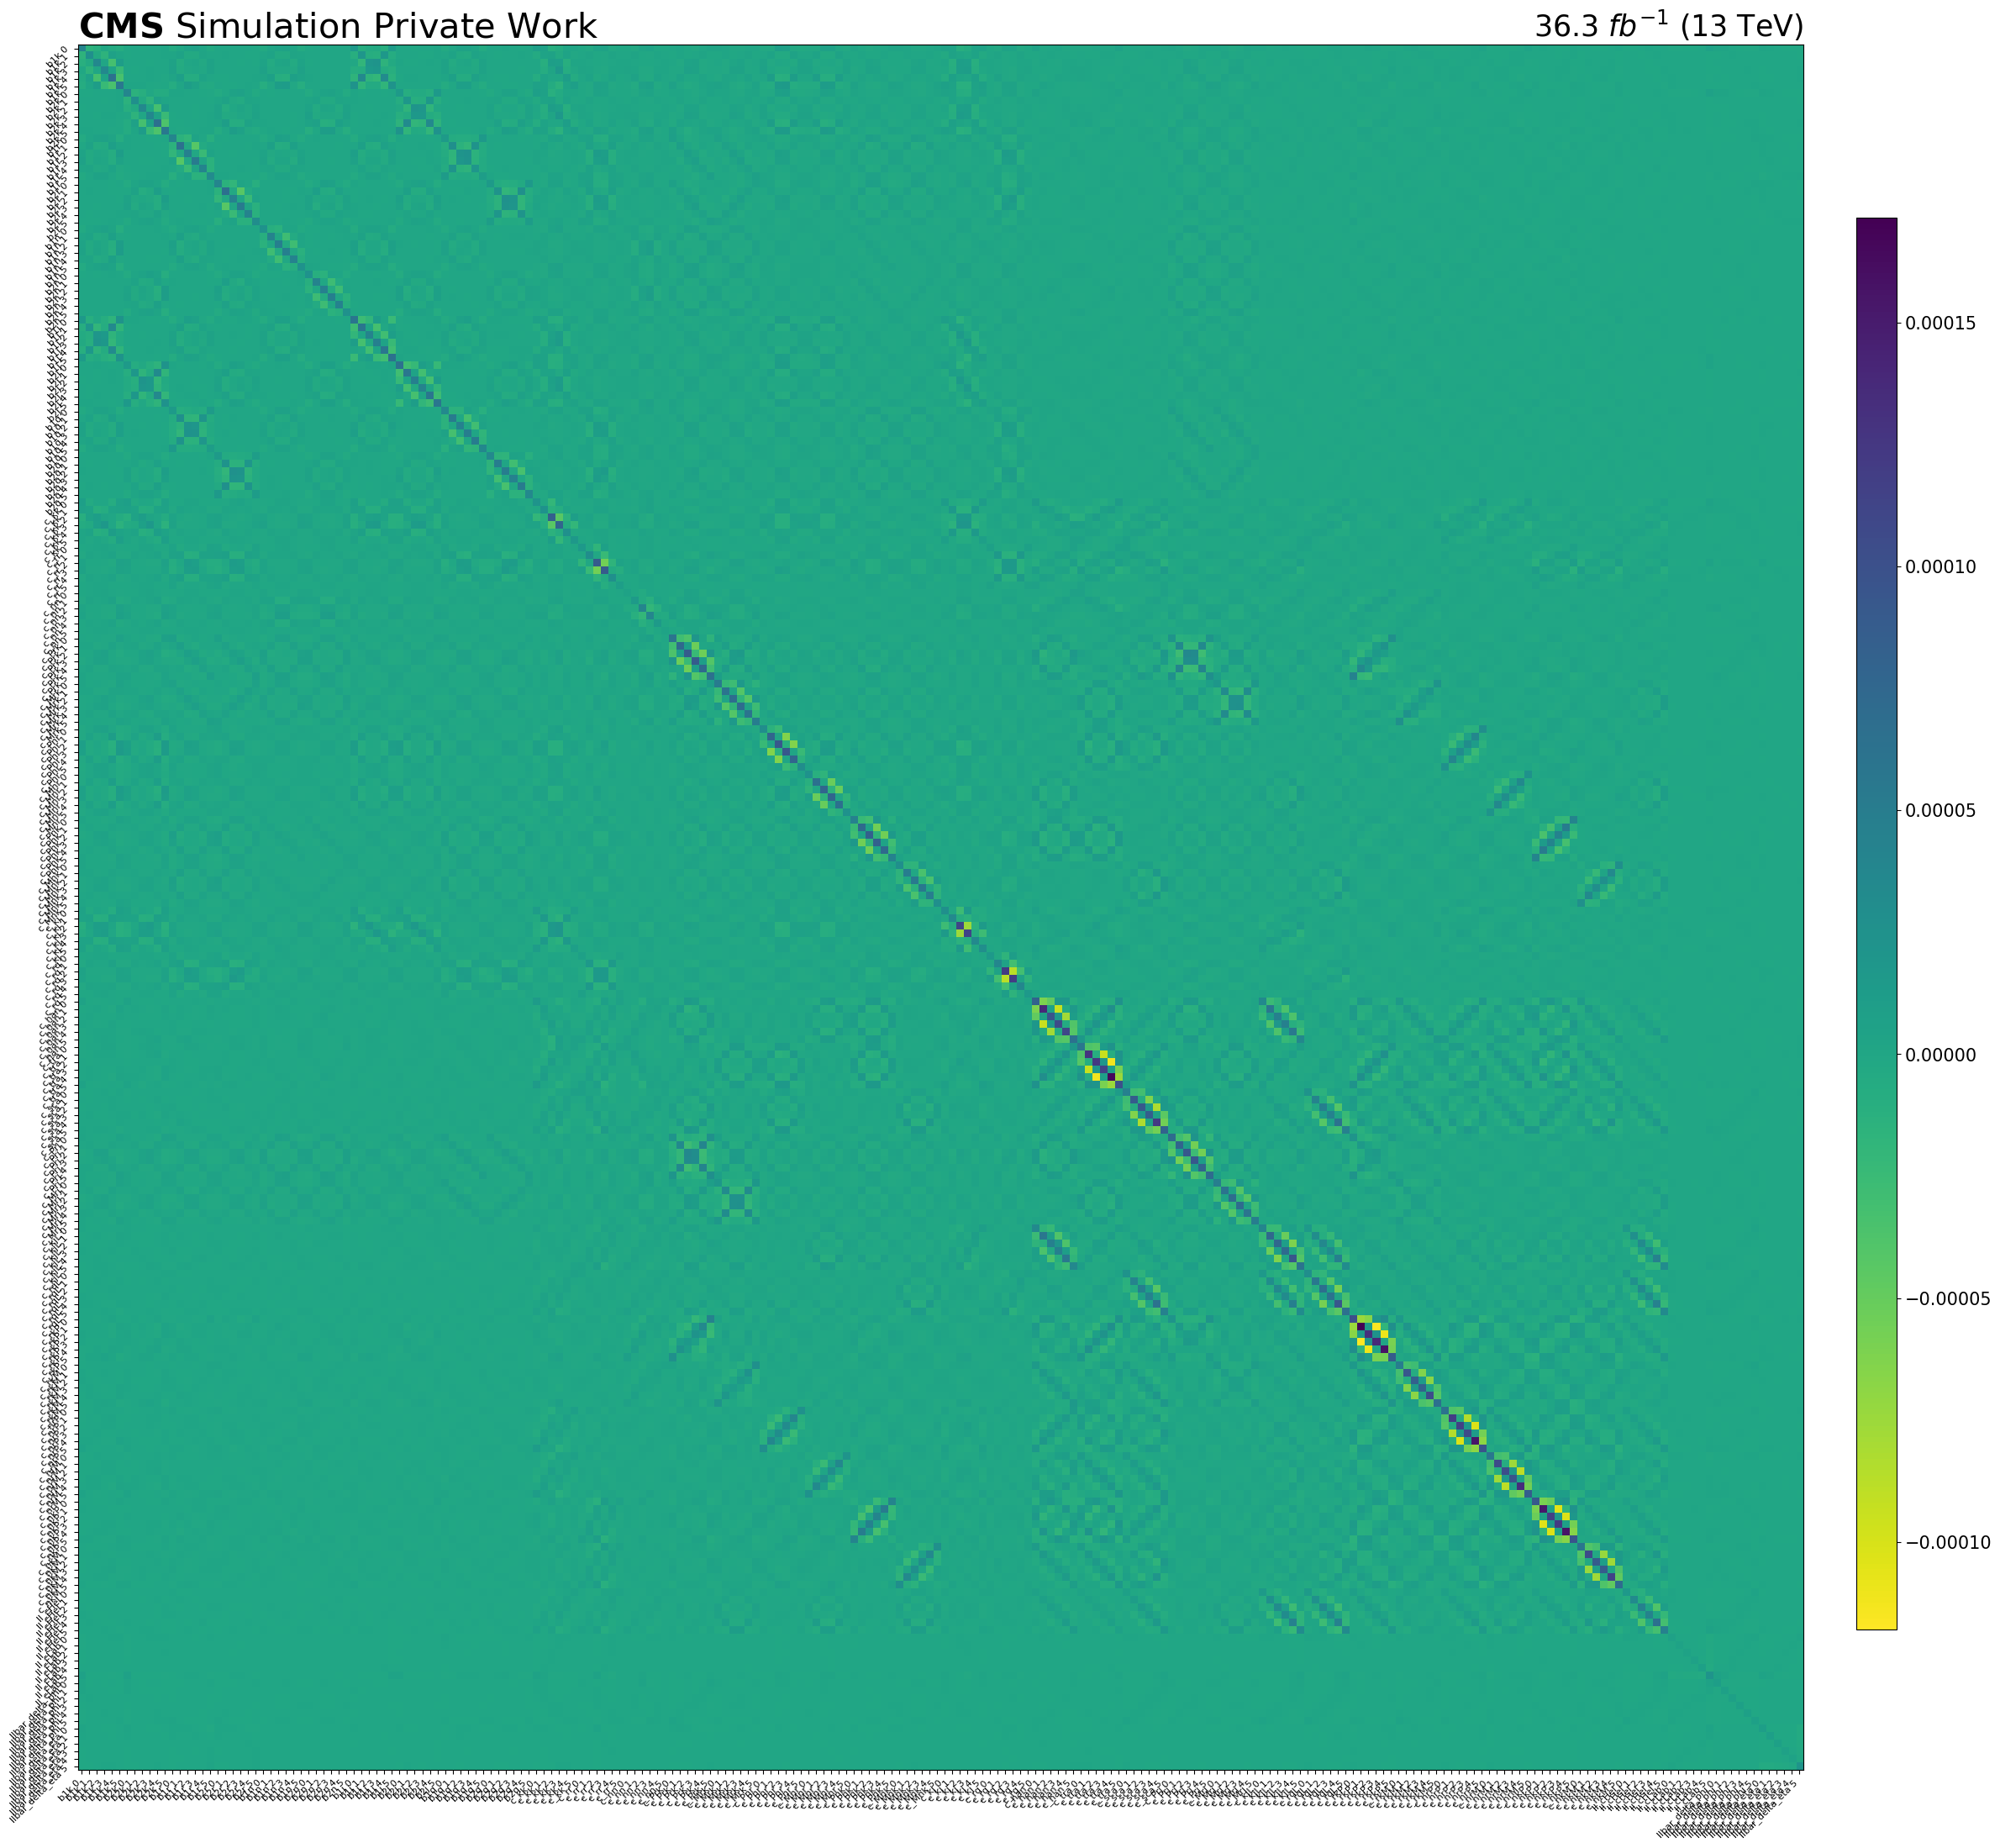

In [290]:
stat_cov_matrix = [] 
stat_cov_matrix = hist_stat["stat_1D_variables;1"]["CovMatrix_Norm"].array()

# Flip the matrix vertically
#stat_cov_matrix = np.flipud(stat_cov_matrix)

# Shape info
n_bins = len(stat_cov_matrix)

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(24, 24))

im = axs.imshow(stat_cov_matrix, cmap='viridis_r')

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_xticks(np.arange(n_bins))
axs.set_xticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

axs.set_yticks(np.arange(n_bins))
axs.set_yticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=15)

axs.set_ylim(n_bins - 0.5, -0.5)  # to keep y-axis in correct order

# Optional: save to PDF
plt.savefig('stat_matrix_from_root.pdf')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar
plt.show()

/tmp/ipykernel_70440/2595808050.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar


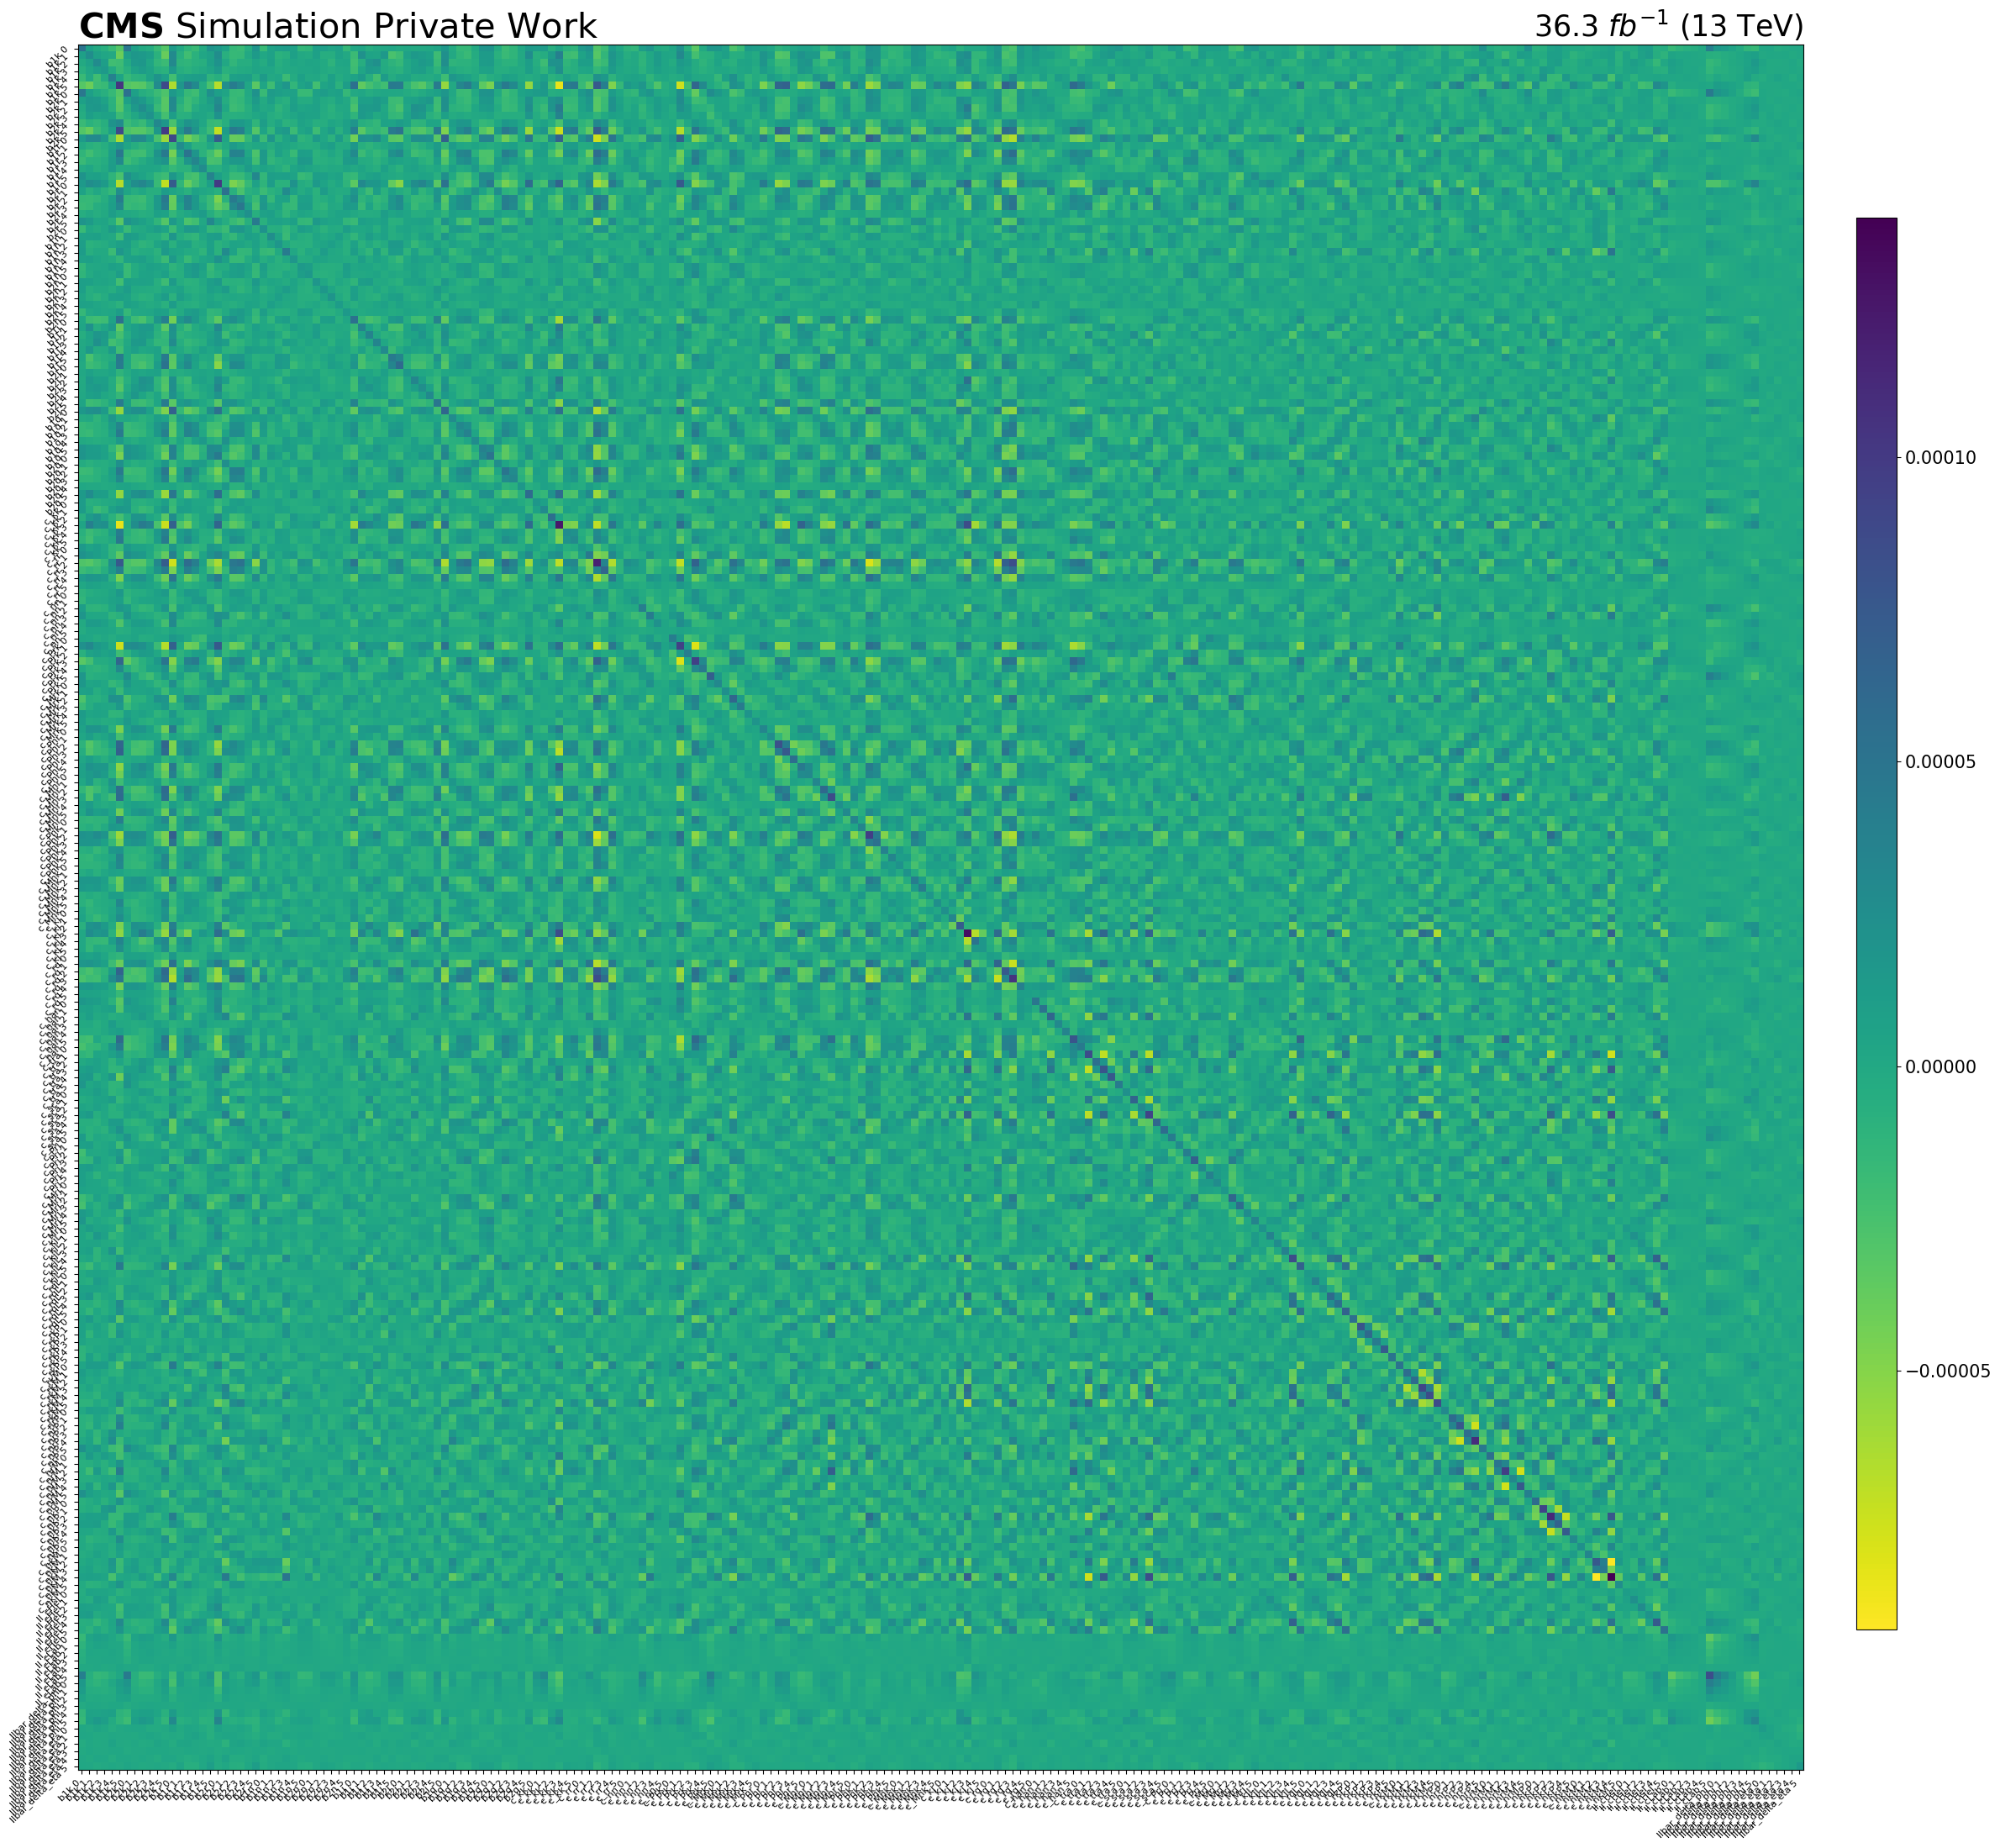

In [291]:
syst_cov_matrix = [] 
syst_cov_matrix = hist_syst["syst_1D_variables;1"]["CovMatrix_Norm"].array()

# Flip the matrix vertically
#syst_cov_matrix = np.flipud(syst_cov_matrix)

# Shape info
n_bins = len(syst_cov_matrix)

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(24, 24))

im = axs.imshow(syst_cov_matrix, cmap='viridis_r')

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_xticks(np.arange(n_bins))
axs.set_xticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

axs.set_yticks(np.arange(n_bins))
axs.set_yticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=15)

axs.set_ylim(n_bins - 0.5, -0.5)  # to keep y-axis in correct order

# Optional: save to PDF
plt.savefig('syst_matrix_from_root.pdf')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar
plt.show()

finalcov = np.add( stat_cov_matrix, syst_cov_matrix )

bins_to_drop = [i for i in range(1, len(finalcov[0]), 6)]  # Starts at 1, skips every 6 bins
finalcov = np.delete(np.delete(finalcov, np.arange(1, len(finalcov[0]), 6), axis=0), np.arange(1, len(finalcov[1]), 6), axis=1)

# Define the bins to drop: the second bin of every 6-bin group

# observable_indices = np.array([10, 12, 13, 19])
# row_col_indices = np.concatenate([np.arange(i * 5, i * 5 + 5) for i in observable_indices])

# # Use np.ix_ to extract the submatrix
# finalcov = finalcov[np.ix_(row_col_indices, row_col_indices)]

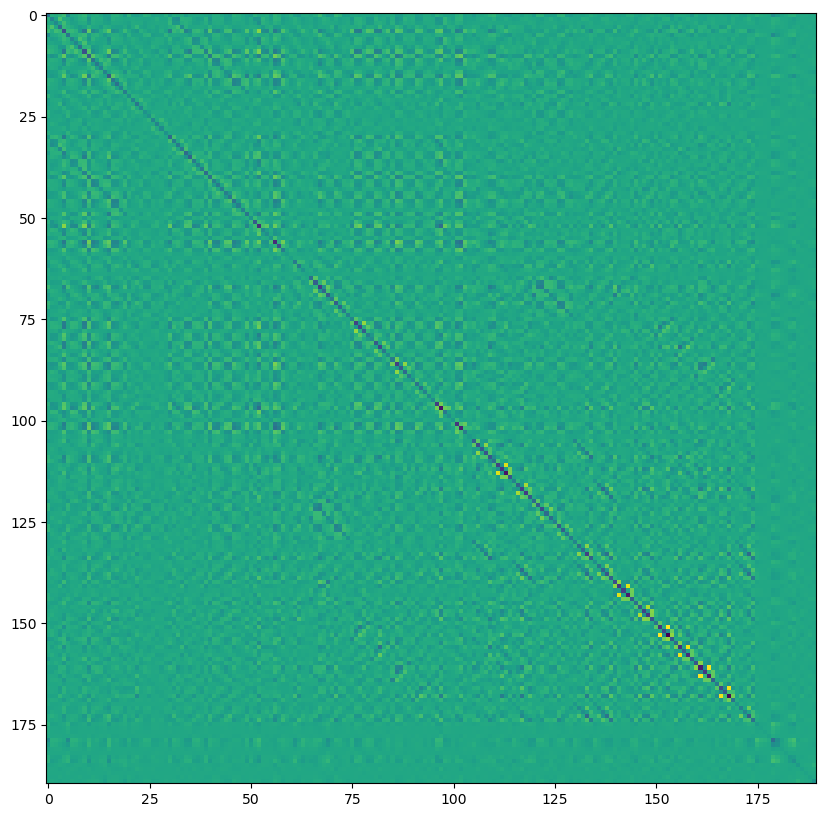

In [292]:
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
im = axs.imshow(finalcov, cmap='viridis_r')

# Prepare covariance matrix input for EFTFitter (almost there)

In [294]:
# Create a ROOT file and TH2F
root_file = ROOT.TFile("covariance_matrix/final_covariance_matrix.root", "RECREATE")
histogram = ROOT.TH2D("covariance_matrix", "Final Covariance Matrix", 
                      len(finalcov[0]), 0, len(finalcov[0]), len(finalcov[1]), 0, len(finalcov[1]))

# Fill the histogram with the matrix values
for i in range(len(finalcov[0])):
    for j in range(np.shape(finalcov)[0]):
        histogram.SetBinContent(i+1, j+1, finalcov[i, j])

# Write the histogram to the ROOT file
histogram.Write()

# Close the ROOT file
root_file.Close()

In [295]:
!ls ./covariance_matrix/ -ltrh

total 256K
-rw-r--r-- 1 he614 4360 121K Feb 25 19:46 statistical_covariance_matrix.root
-rw-r--r-- 1 he614 4360 265K Apr 19 00:00 final_covariance_matrix.root


In [296]:
hepdata_final_cov_matrix['covariance_matrix'].to_hist()

Hist(
  Regular(190, 0, 190, name='xaxis'),
  Regular(190, 0, 190, name='yaxis'),
  storage=Double()) # Sum: 0.006905553324611942

In [297]:
covmat.to_numpy

<bound method Histogram.to_numpy of Hist(
  Regular(190, 0, 190, name='xaxis'),
  Regular(190, 0, 190, name='yaxis'),
  storage=Double()) # Sum: 0.006905553324611942>

In [298]:
np.shape(covmat)

(190, 190)

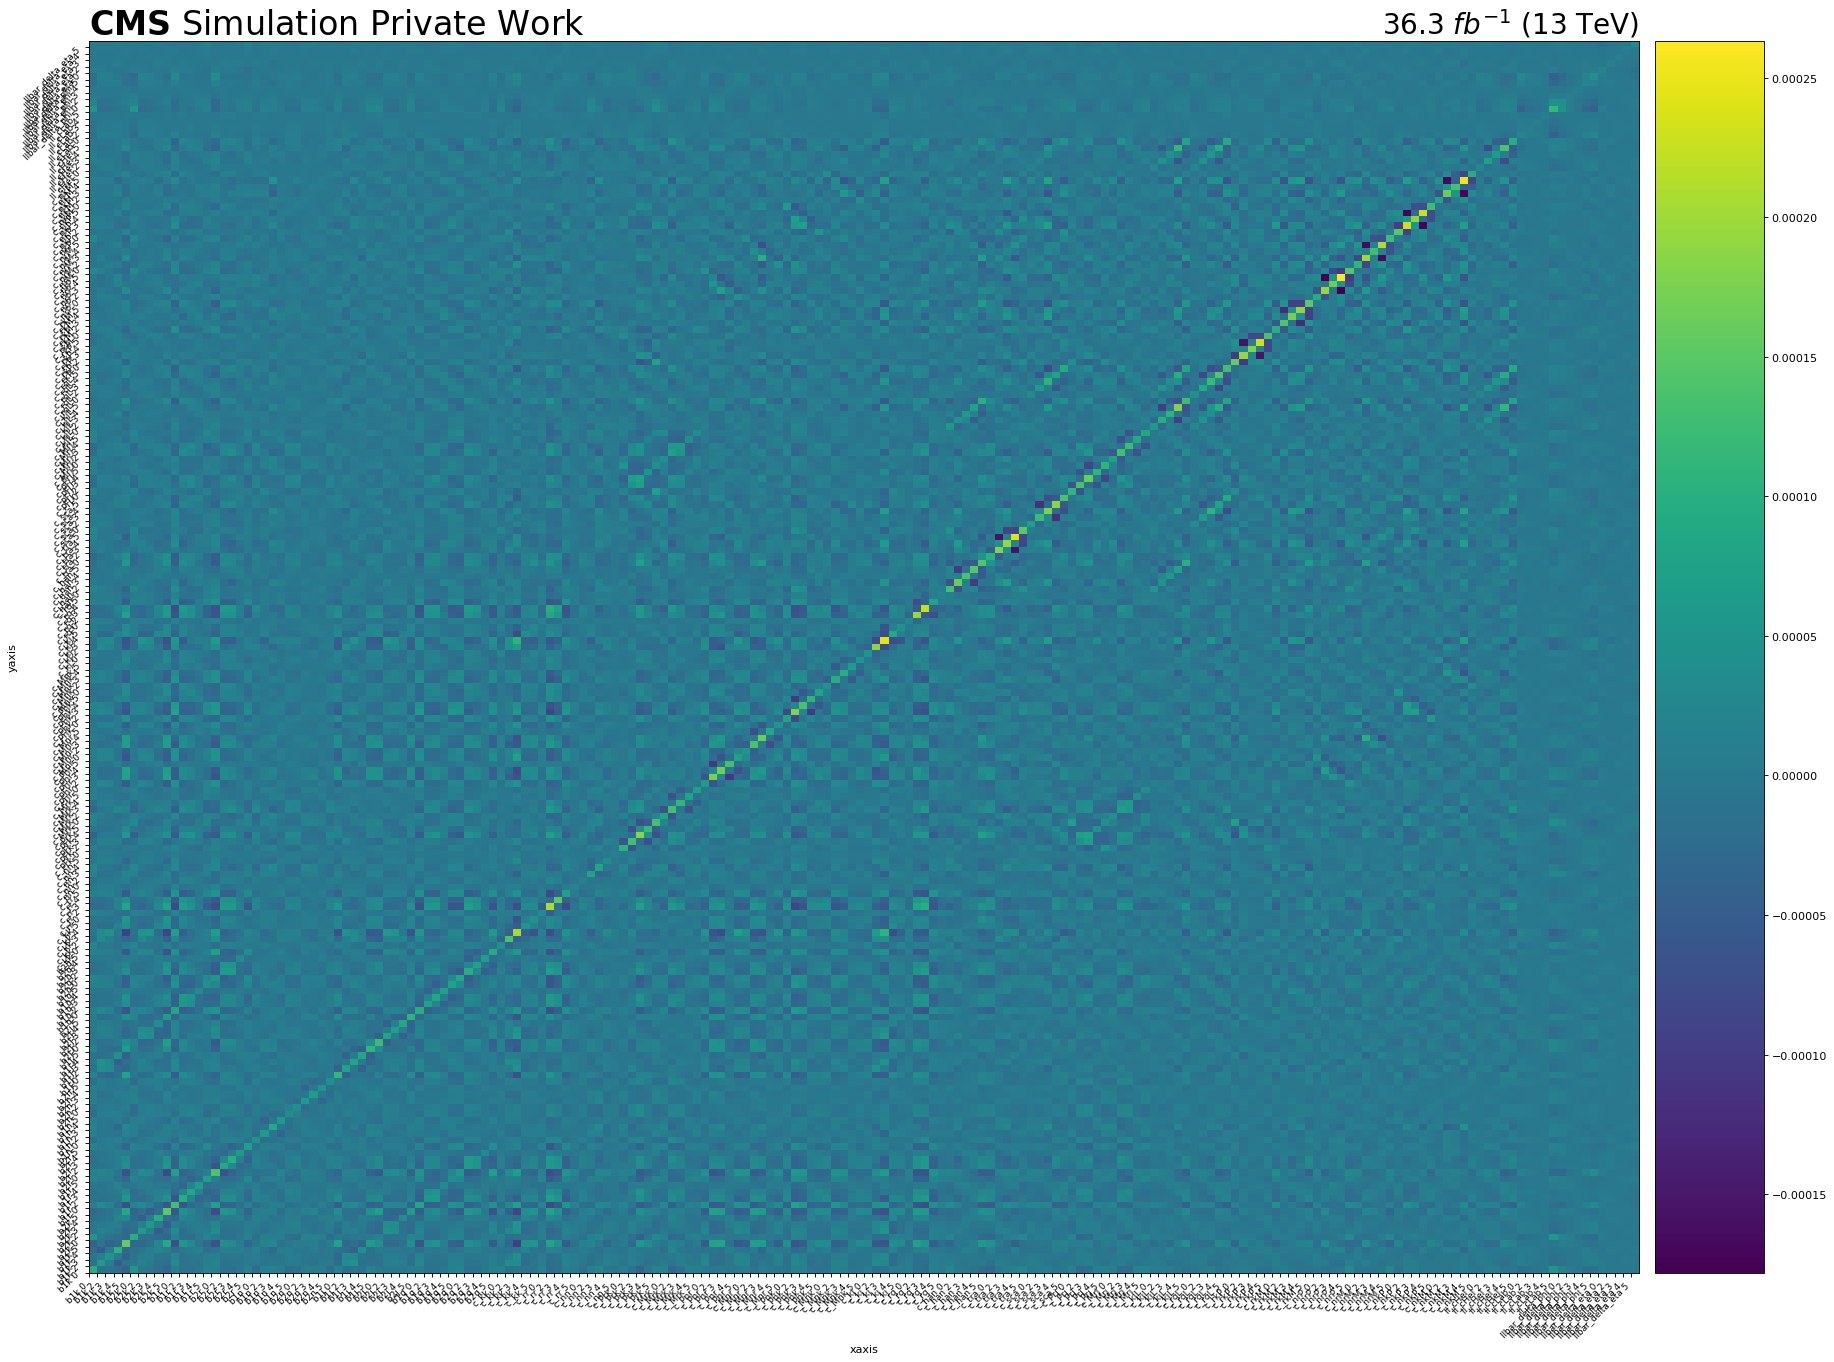

In [293]:
hepdata_final_cov_matrix = uproot.open("covariance_matrix/final_covariance_matrix.root")
hepdata_final_cov_matrix
covmat = hepdata_final_cov_matrix['covariance_matrix'].to_hist()

fig, axs = plt.subplots(1, 1, figsize=(25, 20), dpi=80) 
hepdata_final_cov_matrix['covariance_matrix'].to_hist().plot2d()

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_yticks(np.arange(len(xy_labels_reduced)))
axs.set_yticklabels(xy_labels_reduced, rotation=45, ha='right', fontsize=8)

axs.set_xticks(np.arange(len(xy_labels_reduced)))
axs.set_xticklabels(xy_labels_reduced, rotation=45, ha='right', fontsize=8)
fig.savefig('finalcov.pdf')

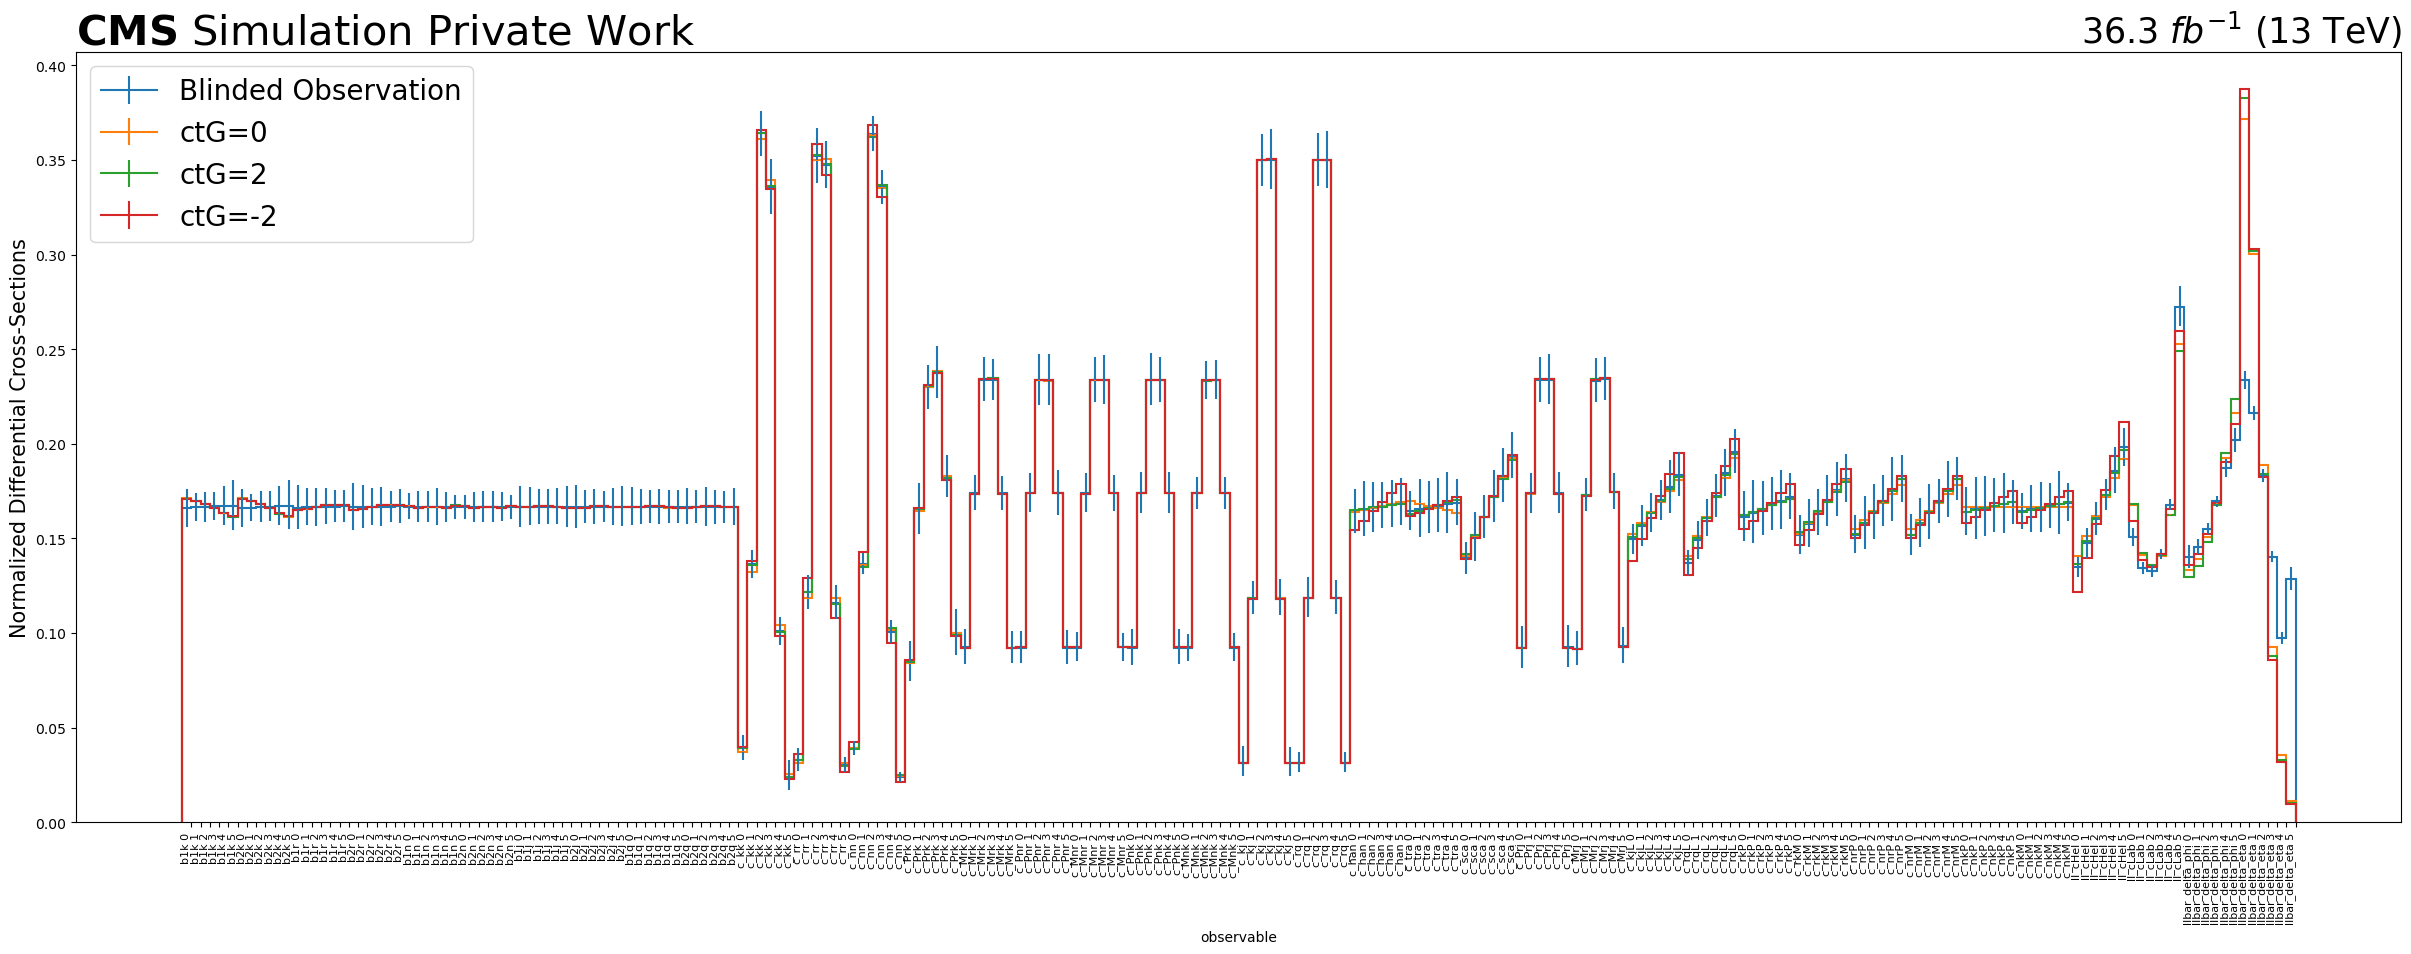

In [299]:
h_concatenated_EFT = {}

op_values = ['0', '2', '-2']

h_concatenated = uproot.open("concatenated_histograms.root")['diff_cross_section'].to_hist()
for value in op_values:
    h_concatenated_EFT[value] = uproot.open(f'concatenated_histograms_ctg{value}.root')['diff_cross_section'].to_hist()

fig, axs = plt.subplots(1, 1, figsize=(30, 10), dpi=100)

h_concatenated.plot1d(label='Blinded Observation')
for value in h_concatenated_EFT:
    h_concatenated_EFT[value].plot1d(label=f'ctG={value}')

axs.legend(fontsize=20)
axs.set_ylabel("Normalized Differential Cross-Sections", fontsize=15)
axs.set_xticks(np.arange(len(xy_labels))+1.0)
axs.set_xticklabels(xy_labels, rotation=90, ha='right', fontsize=8)

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")
#axs.tight_layout()  # Automatically adjusts spacing
fig.savefig("concatenated_histograms.pdf", bbox_inches='tight')  # Ensures labels are not cut

# interpolate the values of a quadratic function as a function of op formed by these 3 histograms formed corresponding parameter op_values = ['p0', 'p2', 'm2']

In [329]:
cov_inv

array([[ 1.50556477e+06, -6.83003148e+05, -1.07607071e+05, ...,
        -3.49730082e+03, -1.36368112e+03, -8.32595669e+03],
       [-6.83003148e+05,  1.32424477e+06,  8.10648752e+05, ...,
        -3.52532028e+03, -1.05030680e+04,  1.17098439e+03],
       [-1.07607071e+05,  8.10648752e+05,  6.65477948e+05, ...,
        -8.13502744e+03, -1.54027553e+04, -4.56029390e+03],
       ...,
       [-3.49730082e+03, -3.52532028e+03, -8.13502744e+03, ...,
         2.62417307e+05,  1.10024934e+05,  1.05447557e+05],
       [-1.36368112e+03, -1.05030680e+04, -1.54027553e+04, ...,
         1.10024934e+05,  2.85829883e+05,  1.00433583e+05],
       [-8.32595669e+03,  1.17098439e+03, -4.56029390e+03, ...,
         1.05447557e+05,  1.00433583e+05,  1.21958292e+05]])

In [330]:
keep_indices

array([  0,   2,   3,   4,   5,   6,   8,   9,  10,  11,  12,  14,  15,
        16,  17,  18,  20,  21,  22,  23,  24,  26,  27,  28,  29,  30,
        32,  33,  34,  35,  36,  38,  39,  40,  41,  42,  44,  45,  46,
        47,  48,  50,  51,  52,  53,  54,  56,  57,  58,  59,  60,  62,
        63,  64,  65,  66,  68,  69,  70,  71,  72,  74,  75,  76,  77,
        78,  80,  81,  82,  83,  84,  86,  87,  88,  89,  90,  92,  93,
        94,  95,  96,  98,  99, 100, 101, 102, 104, 105, 106, 107, 108,
       110, 111, 112, 113, 114, 116, 117, 118, 119, 120, 122, 123, 124,
       125, 126, 128, 129, 130, 131, 132, 134, 135, 136, 137, 138, 140,
       141, 142, 143, 144, 146, 147, 148, 149, 150, 152, 153, 154, 155,
       156, 158, 159, 160, 161, 162, 164, 165, 166, 167, 168, 170, 171,
       172, 173, 174, 176, 177, 178, 179, 180, 182, 183, 184, 185, 186,
       188, 189, 190, 191, 192, 194, 195, 196, 197, 198, 200, 201, 202,
       203, 204, 206, 207, 208, 209, 210, 212, 213, 214, 215, 21

Covariance matrix diagnostics:
  Shape: (190, 190)
  Diagonal min: 6.384e-06
  Diagonal max: 2.627e-04
  Condition number: 1.77e+05


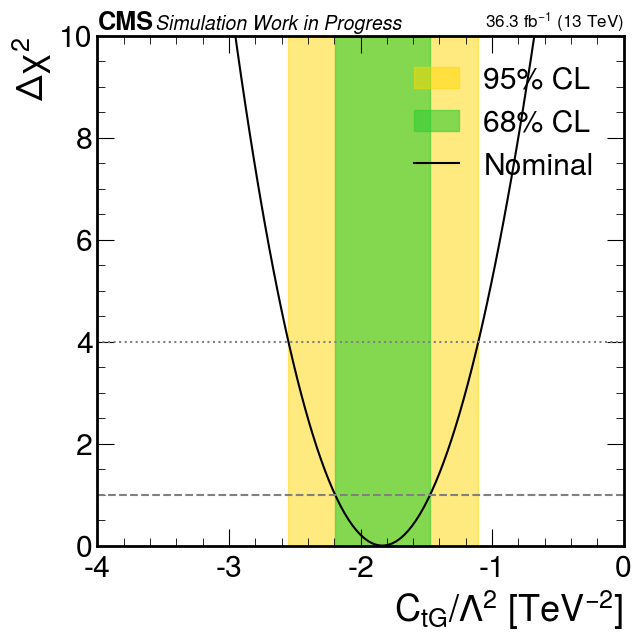


=== Confidence Interval Summary ===
Best fit value of C_G/Λ²: -1.833973
68% CL range         : [-2.193515, -1.470486]
→ Width              : 0.723029
95% CL range         : [-2.548180, -1.104272]
→ Width              : 1.443908

=== Δχ² Values for Input EFT Points ===
ctG = -8.0:  χ² = 4454.648834,  Δχ² = 480.049387
ctG = -4.0:  χ² = 4014.793286,  Δχ² = 40.193839
ctG = -2.0:  χ² = 3974.810817,  Δχ² = 0.211370
ctG =  0.0:  χ² = 3999.901087,  Δχ² = 25.301640
ctG =  2.0:  χ² = 4094.116294,  Δχ² = 119.516847
ctG =  4.0:  χ² = 4297.684871,  Δχ² = 323.085424
ctG =  8.0:  χ² = 5374.677042,  Δχ² = 1400.077595


In [14]:
# import uproot
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d

def normalize_cov_to_corr(covmat):
    diag = np.sqrt(np.diag(covmat))
    outer = np.outer(diag, diag)
    corrmat = covmat / outer
    corrmat[covmat == 0] = 0  # handle zero-variance entries safely
    return corrmat

# --- CMS Plot Style ---
plt.figure(figsize=(7, 7))
hep.style.use("CMS")

# --- Load EFT histograms ---
op_values = ['-8', '-4', '-2', '0', '2', '4', '8']
op_numeric = {
    "-8": -8.0,
    "-4": -4.0,
    "-2": -2.0,
    "0": 0.0,
    "2": 2.0,
    "4": 4.0,
    "8": 8.0
}

h_concatenated_EFT = {
    v: uproot.open(f'concatenated_histograms_ctg{v}.root')['diff_cross_section'].to_hist()
    for v in op_values
}
h_concatenated = uproot.open("concatenated_histograms.root")['diff_cross_section'].to_hist()

# --- Load and reduce covariance matrix ---
covmat, _, _ = uproot.open("covariance_matrix/final_covariance_matrix.root")['covariance_matrix'].to_numpy()
covmat = covmat
n_cov = covmat.shape[0]

# --- Drop every 2nd bin in each 6-bin block to reduce to 190 bins ---
all_indices = np.arange(228)
block_structure = all_indices.reshape(-1, 6)  # 38 observables × 6 bins
mask = np.ones_like(block_structure, dtype=bool)
mask[:, 1] = False  # drop 2nd bin in each block (index 1)
keep_indices = block_structure[mask].flatten()

# --- Get SM values from reduced bins ---
sm_vals = h_concatenated.values()[keep_indices]

# --- Normalize EFT histograms to SM integral ---
sm_total = np.sum(sm_vals)
preds = {}
for k, h in h_concatenated_EFT.items():
    vals = h.values()[keep_indices]
    preds[k] = vals / np.sum(vals) * sm_total

# --- Covariance matrix diagnostics ---
print("Covariance matrix diagnostics:")
print(f"  Shape: {covmat.shape}")
print(f"  Diagonal min: {np.min(np.diag(covmat)):.3e}")
print(f"  Diagonal max: {np.max(np.diag(covmat)):.3e}")
print(f"  Condition number: {np.linalg.cond(covmat):.2e}")
if np.any(np.diag(covmat) <= 0):
    raise ValueError("Covariance matrix has non-positive entries!")

cov_inv = np.linalg.inv(covmat)

# --- Interpolation for EFT prediction ---
def interpolate_prediction(wc):
    wc_vals = np.array([op_numeric[k] for k in op_values])
    pred_matrix = np.vstack([preds[k] for k in op_values])
    pred_interp = []
    for i in range(n_cov):
        coeffs = np.polyfit(wc_vals, pred_matrix[:, i], 2)
        pred_interp.append(np.polyval(coeffs, wc))
    return np.array(pred_interp)

# --- Chi-squared function ---
def chi2(wc):
    pred = interpolate_prediction(wc)
    diff = sm_vals - pred
    return float(diff @ cov_inv @ diff)

# --- Fit and scan ---
res = minimize_scalar(chi2, bounds=(-5, 5), method='bounded')
wc_best = res.x
chi2_min = res.fun
wc_grid = np.linspace(wc_best - 3, wc_best + 3, 200)
chi2_vals = np.array([chi2(wc) for wc in wc_grid])
dchi2_vals = chi2_vals - chi2_min

# Find 68% and 95% CL boundaries by splitting left/right sides
left_mask = wc_grid < wc_best
right_mask = wc_grid > wc_best

interp_left = interp1d(dchi2_vals[left_mask], wc_grid[left_mask],
                       kind='linear', bounds_error=False, fill_value='extrapolate')
interp_right = interp1d(dchi2_vals[right_mask], wc_grid[right_mask],
                        kind='linear', bounds_error=False, fill_value='extrapolate')

w1_lo = float(interp_left(1.0))
w1_hi = float(interp_right(1.0))
w2_lo = float(interp_left(4.0))
w2_hi = float(interp_right(4.0))

# Highlight 95% and 68% CL bands (horizontal extent only in x)
plt.axvspan(w2_lo, w2_hi, color='gold', alpha=0.5, label='95% CL')
plt.axvspan(w1_lo, w1_hi, color='limegreen', alpha=0.6, label='68% CL')

# Δχ² curves
plt.plot(wc_grid, dchi2_vals, color='black', label='Nominal')
#plt.plot(wc_grid, dchi2_vals * 1.15, color='blue', linestyle='dotted', label='+ theory')
#plt.plot(wc_grid, dchi2_vals * 0.85, color='red', linestyle='--', label='− theory')

# Reference lines
plt.axhline(1.0, color='gray', linestyle='--')
plt.axhline(4.0, color='gray', linestyle=':')

# Axis labels & style
plt.xlabel(r'$C_{tG} / \Lambda^2$ [TeV$^{-2}$]')
plt.ylabel(r'$\Delta \chi^2$')
plt.ylim(0, 10)
plt.xlim(-4, 0)
plt.legend(loc='upper right')

# CMS labels
hep.cms.text("Simulation Work in Progress", loc=0, fontsize=14)
hep.cms.lumitext("36.3 fb$^{-1}$ (13 TeV)", fontsize=13)

plt.tight_layout()
plt.savefig("ctG_CMSstyle_DeltaChi2.pdf")
plt.show()

# --- Print results ---
print("\n=== Confidence Interval Summary ===")
print(f"Best fit value of C_G/Λ²: {wc_best:.6f}")
print(f"68% CL range         : [{min(w1_lo, w1_hi):.6f}, {max(w1_lo, w1_hi):.6f}]")
print(f"→ Width              : {abs(w1_hi - w1_lo):.6f}")
print(f"95% CL range         : [{min(w2_lo, w2_hi):.6f}, {max(w2_lo, w2_hi):.6f}]")
print(f"→ Width              : {abs(w2_hi - w2_lo):.6f}")

print("\n=== Δχ² Values for Input EFT Points ===")
for label, wc_val in op_numeric.items():
    chi2_val = chi2(wc_val)
    delta_chi2 = chi2_val - chi2_min
    print(f"ctG = {wc_val:>4}:  χ² = {chi2_val:.6f},  Δχ² = {delta_chi2:.6f}")


In [174]:
!ls ./example_fit_input/ut_coeff.root -ltrh

-rw-r--r-- 1 he614 4360 14K Feb 23 07:55 ./example_fit_input/ut_coeff.root


In [175]:
check_file = uproot.open('./example_fit_input/ut_coeff.root')

In [176]:
check_file.keys()

['sm_nominal;1',
 'sm_up;1',
 'sm_down;1',
 'ut_nominal;1',
 'ut_up;1',
 'ut_down;1',
 'sm_nominal_plus_ut_nominal;1',
 'sm_nominal_plus_ut_up;1',
 'sm_nominal_plus_ut_down;1',
 'sm_up_plus_ut_nominal;1',
 'sm_up_plus_ut_up;1',
 'sm_up_plus_ut_down;1',
 'sm_down_plus_ut_nominal;1',
 'sm_down_plus_ut_up;1',
 'sm_down_plus_ut_down;1',
 'sm_nominal_minus_ut_nominal;1',
 'sm_nominal_minus_ut_up;1',
 'sm_nominal_minus_ut_down;1',
 'sm_up_minus_ut_nominal;1',
 'sm_up_minus_ut_up;1',
 'sm_up_minus_ut_down;1',
 'sm_down_minus_ut_nominal;1',
 'sm_down_minus_ut_up;1',
 'sm_down_minus_ut_down;1']